# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import floor
import matplotlib.ticker as mtick
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
print('Everything is Imported Boss')

Everything is Imported Boss


# **Data Exploration**

## **Load the Data**

In [2]:
file_path = input("Enter the File Path Baby: ")
df = pd.read_csv(file_path)
print('Data Loaded Baby')

Data Loaded Baby


## **Exploration**

In [3]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 32300 Rows and 10 columns with 296 Duplicates


In [4]:
df.head()

,annual_income,monthly_spend,avg_basket_size,purchase_frequency,discount_usage_pct,loyalty_points,online_orders_pct,return_rate_pct,customer_age,months_active
0,189934.28,1990.09,393.97,3.33,80.86,729.22,34.86,6.14,43.49,14.65
1,177234.71,1848.90,351.97,3.29,62.11,951.91,24.17,6.71,43.39,18.86
2,192953.77,1948.29,304.38,5.43,69.59,770.27,27.84,6.40,42.88,13.98
3,210460.6,2214.42,326.88,5.86,64.06,813.59,28.24,5.41,51.34,13.14
4,175316.93,2383.36,367.14,3.07,76.51,907.61,29.88,5.53,51.82,17.01


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32300 entries, 0 to 32299
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   annual_income       31660 non-null  str    
 1   monthly_spend       31655 non-null  float64
 2   avg_basket_size     31657 non-null  float64
 3   purchase_frequency  31651 non-null  float64
 4   discount_usage_pct  31654 non-null  float64
 5   loyalty_points      31658 non-null  float64
 6   online_orders_pct   31653 non-null  float64
 7   return_rate_pct     31655 non-null  float64
 8   customer_age        31656 non-null  float64
 9   months_active       31653 non-null  float64
dtypes: float64(9), str(1)
memory usage: 2.7 MB


In [6]:
df.describe()

,monthly_spend,avg_basket_size,purchase_frequency,discount_usage_pct,loyalty_points,online_orders_pct,return_rate_pct,customer_age,months_active
count,31655.000000,31657.000000,31651.000000,31654.000000,31658.000000,31653.000000,31655.000000,31656.000000,31653.000000
mean,9447.008118,1281.701133,9.401179,53.070470,4352.638786,57.530688,11.393938,37.455986,34.114008
std,8648.755537,1212.128143,4.358322,30.384786,4235.727898,20.466853,6.341846,9.137550,17.025596
min,-2000.000000,157.180000,1.000000,0.000000,155.690000,2.630000,-10.000000,-5.000000,1.000000
25%,3001.625000,448.040000,5.520000,29.792500,1201.927500,40.600000,6.360000,30.520000,20.740000
50%,6980.920000,825.150000,8.990000,49.970000,2991.780000,60.020000,9.550000,37.340000,29.930000
75%,9020.930000,1077.200000,13.000000,82.390000,4017.667500,74.220000,16.380000,43.940000,44.640000
max,35693.380000,5012.880000,22.270000,150.000000,17517.290000,100.000000,33.710000,73.290000,93.270000


In [7]:
df.isna().sum()

annual_income         640
monthly_spend         645
avg_basket_size       643
purchase_frequency    649
discount_usage_pct    646
loyalty_points        642
online_orders_pct     647
return_rate_pct       645
customer_age          644
months_active         647
dtype: int64

# **Data Cleaning**

## **Create Copy**

In [31]:
df_copy = df.copy()
print("Copy Created")

Copy Created


## **DataType**

In [32]:
df_copy['annual_income'] = df_copy['annual_income'].replace('_err','',regex=True).astype('float')

## **Impossible Values**

In [33]:
Columns = ['annual_income','monthly_spend','return_rate_pct','customer_age']
for col in Columns:
    df_copy.loc[df_copy[col]<0,col] = np.nan
    
df_copy.loc[df_copy['discount_usage_pct']>100,'discount_usage_pct'] = np.nan

df_copy.loc[df_copy['customer_age']>100,'customer_age'] = np.nan

## **Outliers**

In [34]:
columns = ['annual_income','monthly_spend','loyalty_points']

for col in columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## **Duplicates**

In [35]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 299
After: 0


## **NaN Values**

In [36]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())
Floor = ['customer_age']
for col in Floor:
    df_copy[col] = df_copy[col].fillna(floor(df_copy[col].median()))
    
Round = ['annual_income',
         'monthly_spend',
         'avg_basket_size',
         'purchase_frequency',
         'discount_usage_pct',
         'loyalty_points',
         'online_orders_pct',
         'return_rate_pct',
         'months_active']
for col in Round:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
print("NaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
annual_income         7042
monthly_spend         7429
avg_basket_size        640
purchase_frequency     640
discount_usage_pct     645
loyalty_points        7440
online_orders_pct      640
return_rate_pct        645
customer_age           645
months_active          640
dtype: int64
NaN values in the Dataset After Cleaning is: 
annual_income         0
monthly_spend         0
avg_basket_size       0
purchase_frequency    0
discount_usage_pct    0
loyalty_points        0
online_orders_pct     0
return_rate_pct       0
customer_age          0
months_active         0
dtype: int64


# **Model**

## **Scaler**

In [38]:
features = df_copy.columns.tolist()

X = df_copy[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.describe().round(2)

,annual_income,monthly_spend,avg_basket_size,purchase_frequency,discount_usage_pct,loyalty_points,online_orders_pct,return_rate_pct,customer_age,months_active
count,32001.00,32001.00,32001.00,32001.00,32001.00,32001.00,32001.00,32001.00,32001.00,32001.00
mean,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.51,-1.77,-0.93,-1.94,-1.76,-1.92,-2.71,-1.81,-2.15,-1.96
25%,-0.72,-0.64,-0.68,-0.87,-0.75,-0.76,-0.81,-0.79,-0.75,-0.78
50%,-0.32,-0.14,-0.37,-0.09,-0.10,-0.08,0.12,-0.29,-0.04,-0.24
75%,0.81,0.95,-0.17,0.82,0.97,0.89,0.81,0.78,0.70,0.61
max,5.01,5.45,3.11,2.98,1.56,5.66,2.09,3.56,3.97,3.51


## **Optimal K**

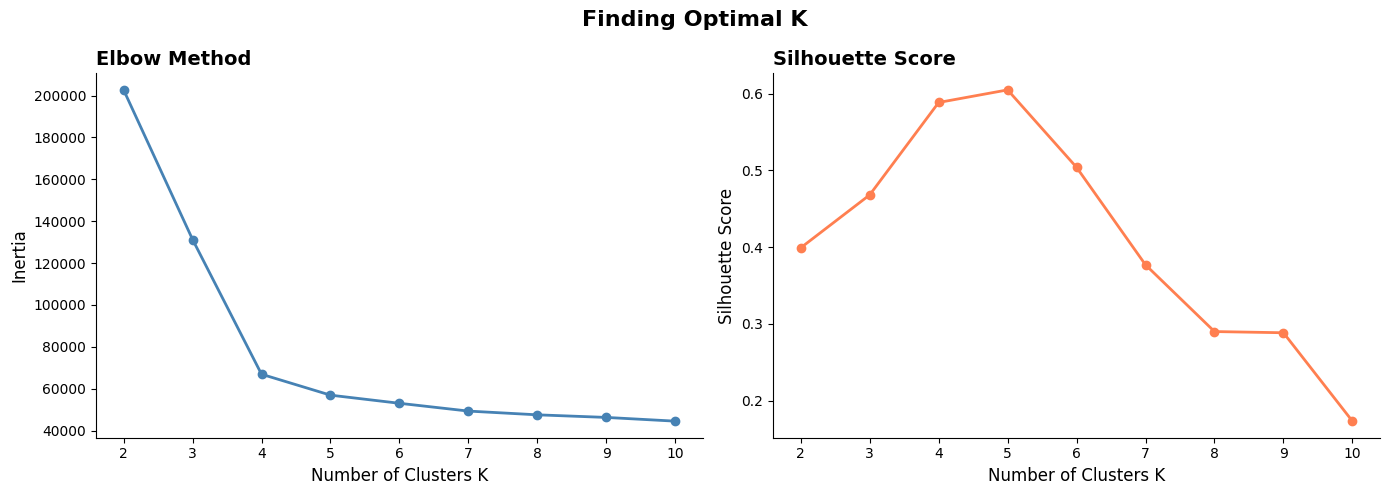

In [39]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Number of Clusters K', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontweight='bold', fontsize=14, loc='left')
axes[0].spines[['right','top']].set_visible(False)

axes[1].plot(K_range, sil_scores, marker='o', color='coral', linewidth=2)
axes[1].set_xlabel('Number of Clusters K', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontweight='bold', fontsize=14, loc='left')
axes[1].spines[['right','top']].set_visible(False)

plt.suptitle('Finding Optimal K', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## **Train**

In [40]:
optimal_k = 5  # set based on your elbow + silhouette analysis

model = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10       # run 10 times with different starting centroids, keep best
)

model.fit(X_scaled)
print(f"Model trained with K={optimal_k} ✅")

Model trained with K=5 ✅


## **Lables**

In [41]:
# Add cluster labels back to original dataframe
df_copy['cluster'] = model.labels_

# How many rows in each cluster
print(df_copy['cluster'].value_counts().sort_index())

cluster
0     8000
1    10025
2     6512
3     7000
4      464
Name: count, dtype: int64


In [43]:
# Compare clusters on every feature
cluster_profile = df_copy.groupby('cluster')[X.columns].mean().round(2)
cluster_profile

,annual_income,monthly_spend,avg_basket_size,purchase_frequency,discount_usage_pct,loyalty_points,online_orders_pct,return_rate_pct,customer_age,months_active
cluster,,,,,,,,,,
0,181655.91,2055.30,359.69,4.09,74.33,825.32,30.64,5.12,44.78,18.26
1,446285.72,7941.59,953.75,8.03,40.11,3477.54,55.14,8.03,35.04,36.02
2,263979.29,4803.24,3450.80,11.90,10.74,2139.23,79.68,14.94,41.79,59.23
3,250116.69,4505.43,603.55,14.90,89.22,1996.85,69.84,19.69,28.21,24.02
4,906606.55,4940.43,3448.38,11.90,10.67,2148.22,79.09,14.87,42.04,59.86


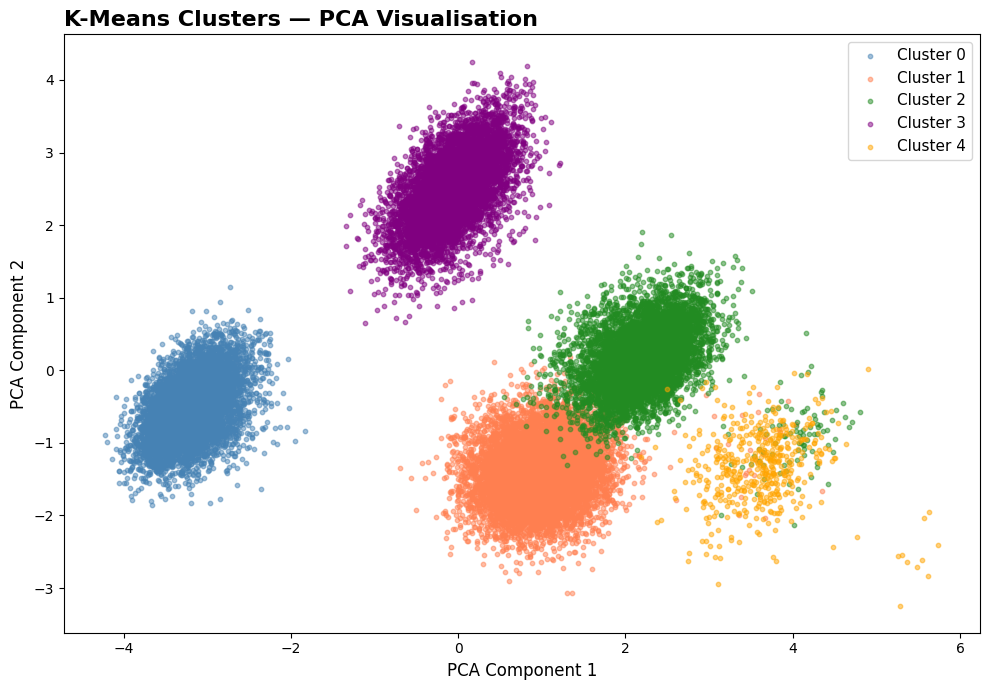

In [44]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
colors = ['steelblue', 'coral', 'forestgreen', 'purple', 'orange']

for cluster_id in range(optimal_k):
    mask = model.labels_ == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[cluster_id], label=f'Cluster {cluster_id}',
                alpha=0.5, s=10)

plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.title('K-Means Clusters — PCA Visualisation',
          fontweight='bold', fontsize=16, loc='left')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

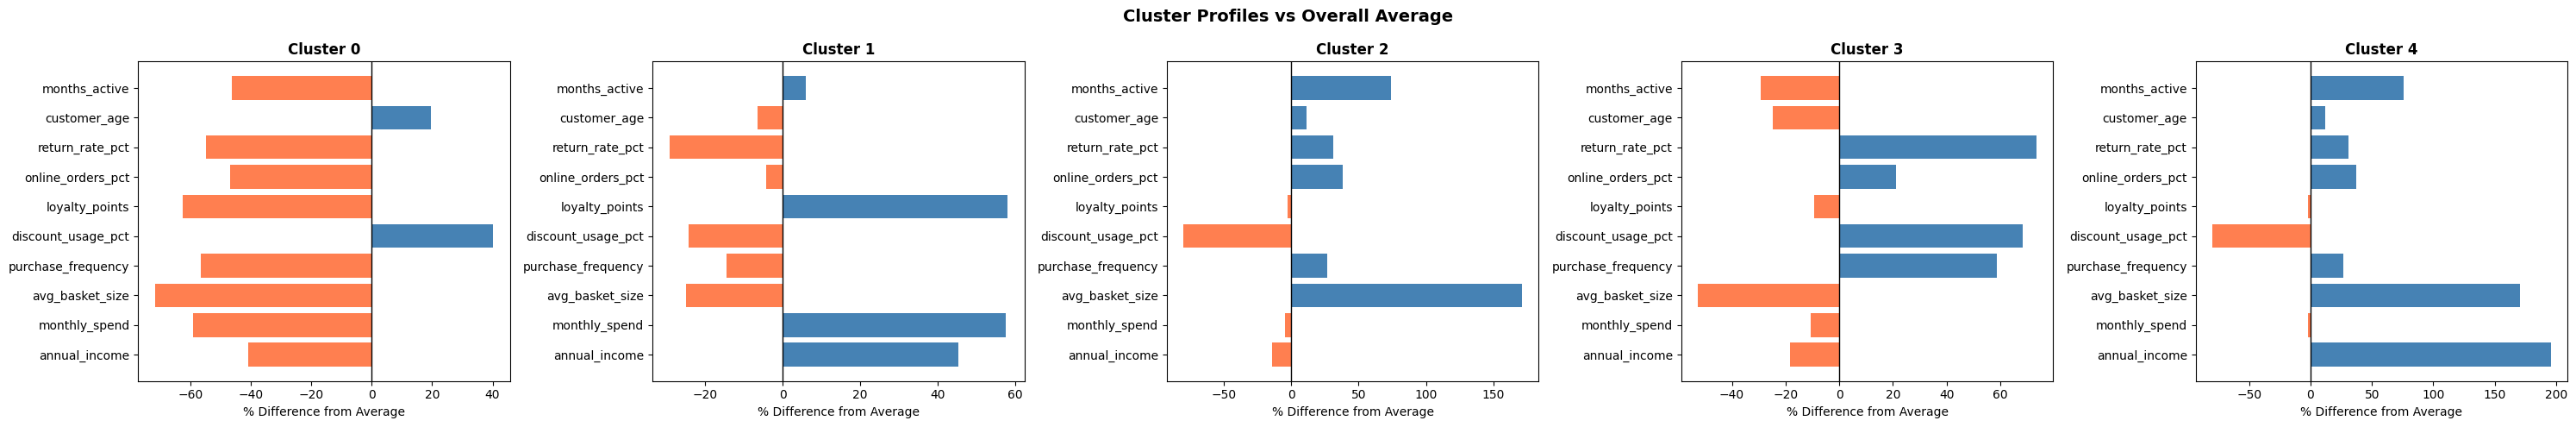

In [48]:
fig, axes = plt.subplots(1, optimal_k, figsize=(6*optimal_k, 5))

for i, ax in enumerate(axes):
    cluster_means = df_copy[df_copy['cluster']==i][X.columns].mean()
    overall_means = df_copy[X.columns].mean()
    diff = ((cluster_means - overall_means) / overall_means * 100).round(1)
    
    colors = ['coral' if v < 0 else 'steelblue' for v in diff]
    ax.barh(diff.index, diff.values, color=colors)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'Cluster {i}', fontweight='bold')
    ax.set_xlabel('% Difference from Average')

plt.suptitle('Cluster Profiles vs Overall Average',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()